# Experiment Density Heatmaps

For a given `motionmapperpy` project (UMAP embedding + watershed segmentation, e.g.
`Results/LargeBlindVisualActivity/`), this notebook overlays the **UMAP point density**
of each of the four stimulus experiments &mdash; Sharp Night, Sharp Day, Soft Night and
Soft Day &mdash; plus the `Observation` baseline condition, on top of the watershed
region map (the same regions shown in `UMAP/zWshed*.png`).

When an experiment was run on both hives (e.g. `SharpDay_hive1` and `SharpDay_hive2`),
its UMAP points are **concatenated across hives** before the density is computed, so
each panel reflects the pooled behavior of every hive that went through that
experiment. An experiment run on a single hive only (e.g. `SoftNight`, currently
hive 1 only) simply uses that hive's points. `Observation` additionally has both an
`upper` and a `lower` hive-level dataset per hive (unlike the Sharp/Soft experiments,
which only have `upper`); all of its matching datasets -- both hives, both levels --
are pooled into the one `Observation` panel the same way.

There is also an `Idle` condition per hive (no stimulus) which is,
behaviorally, essentially the same no-stimulus baseline as `Observation`. By default
(`FUSE_IDLE_OBSERVATION = True` in Section 2) its datasets are pooled into the
`Observation` panel rather than given a panel of their own.

**Prerequisite:** the target project must already have gone through the watershed step
of `Ethogram_Generation_Metabolism.ipynb` (i.e. `UMAP/zVals_wShed_groups.mat` must
exist). This notebook does not re-run PCA/UMAP/watershed, and &mdash; unlike
`Region_Field_Heatmaps.ipynb` &mdash; it does not need the cached per-dataset sensor
dataframes either: the watershed file's own `zValues`/`zValNames`/`zValLens` already
contain every dataset's UMAP embedding, which is all a density plot needs.

Uses the same per-dataset block-alignment logic as `Region_Field_Heatmaps.ipynb` /
`Ethogram_Generation_Metabolism.ipynb`, and the watershed-artifact loader from
`umap_video_utils.py`.

Kernel: `motionmapper37` (same as `Ethogram_Generation_Metabolism.ipynb`).

## 1.&nbsp; Imports

In [23]:
import os, sys
from pathlib import Path

sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots/RHCImaging')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation')
sys.path.append('Metabolism/VisualActivity')
sys.path.append('Metabolism')
sys.path.insert(0, os.path.abspath('motionmapperpy-master'))

import hdf5storage
import numpy as np
import matplotlib.pyplot as plt

import motionmapperpy as mmpy
from umap_video_utils import load_watershed_artifacts

%matplotlib inline

## 2.&nbsp; Configuration

In [24]:
import pickle

# Path to the motionmapperpy project directory (same one used in Ethogram_Generation_Metabolism.ipynb)
projectPath = r"/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHiveNewTiming/"

PROJECT_DIR = Path(projectPath)
PROJECTIONS_DIR = PROJECT_DIR / "Projections"

# parameters.pkl records which method (UMAP/TSNE) was used to build the watershed run, so we
# load it instead of hard-coding the method.
with open(PROJECT_DIR / "parameters.pkl", "rb") as f:
    parameters = pickle.load(f)

UMAP_DIR = PROJECT_DIR / parameters.method
WSHED_PATH = UMAP_DIR / "zVals_wShed_groups.mat"
assert WSHED_PATH.exists(), f"Watershed file not found at {WSHED_PATH}. Run the watershed step of Ethogram_Generation_Metabolism.ipynb first."
print(f"Project: {PROJECT_DIR}")
print(f"Method : {parameters.method}")
print(f"Watershed file: {WSHED_PATH}")

# The experiments to overlay -- must match the {exp} part of the dataset ids
# ({exp}_hive{hive_nb}_{ihl}) produced by the source notebook.
TARGET_EXPERIMENTS = ["SharpDay", "SharpNight", "SoftDay", "SoftNight", "Observation"]

# Idle and Observation are both no-stimulus baseline conditions -- behaviorally similar enough
# that, with this True, Idle's datasets are pooled into the existing "Observation" panel
# (Section 5) instead of being skipped or given a panel of their own. Idle is deliberately not
# listed in TARGET_EXPERIMENTS itself; this flag is what pulls it in.
FUSE_IDLE_OBSERVATION = True

Project: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHiveNewTiming
Method : UMAP
Watershed file: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHiveNewTiming/UMAP/zVals_wShed_groups.mat


## 3.&nbsp; Discover datasets

Dataset identity is taken directly from the `*_pcaModes.mat` files present in
`Projections/`, i.e. exactly the datasets that went into the current watershed run --
not from the experiment config, so this stays correct even if `used_exp_list` changes
in the source notebook. The ihl suffix is optional in the filename, so this
auto-detects whether the project is whole-hive (`{exp}_hive{hive_nb}`, no suffix) or
per-ihl (`{exp}_hive{hive_nb}_{upper,lower}`) -- no config flag needed.

In [25]:
import re

dataset_id_pattern = re.compile(r"^(?P<exp>.+)_hive(?P<hive>\d+)(?:_(?P<ihl>upper|lower))?$")

dataset_keys = []  # list of (exp, hive_nb, ihl); ihl is None for a whole-hive dataset
for pca_file in sorted(PROJECTIONS_DIR.glob("*_pcaModes.mat")):
    source_id = pca_file.name[: -len("_pcaModes.mat")]
    m = dataset_id_pattern.match(source_id)
    if not m:
        print(f"Skipping unrecognized projection file name: {pca_file.name}")
        continue
    dataset_keys.append((m.group("exp"), int(m.group("hive")), m.group("ihl")))

print(f"Found {len(dataset_keys)} datasets in {PROJECTIONS_DIR}:")
for key in dataset_keys:
    print(" ", key)

# When FUSE_IDLE_OBSERVATION is True, Idle datasets get pooled into the Observation panel
# (Section 5) even though "Idle" isn't itself in TARGET_EXPERIMENTS -- include it here too so
# this diagnostic listing matches what actually ends up plotted.
effective_target_experiments = list(TARGET_EXPERIMENTS)
if FUSE_IDLE_OBSERVATION and "Idle" not in effective_target_experiments:
    effective_target_experiments.append("Idle")

target_keys = [key for key in dataset_keys if key[0] in effective_target_experiments]
print(f"\n{len(target_keys)} datasets match the target experiments {effective_target_experiments}:")
for key in target_keys:
    print(" ", key)

Found 12 datasets in /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHiveNewTiming/Projections:
  ('Constant', 2, None)
  ('Idle', 1, None)
  ('Idle', 2, None)
  ('Observation', 1, None)
  ('Observation', 2, None)
  ('SharpDay', 1, None)
  ('SharpDay', 2, None)
  ('SharpNight', 1, None)
  ('SharpNight', 2, None)
  ('SoftDay', 1, None)
  ('SoftDay', 2, None)
  ('SoftNight', 1, None)

11 datasets match the target experiments ['SharpDay', 'SharpNight', 'SoftDay', 'SoftNight', 'Observation', 'Idle']:
  ('Idle', 1, None)
  ('Idle', 2, None)
  ('Observation', 1, None)
  ('Observation', 2, None)
  ('SharpDay', 1, None)
  ('SharpDay', 2, None)
  ('SharpNight', 1, None)
  ('SharpNight', 2, None)
  ('SoftDay', 1, None)
  ('SoftDay', 2, None)
  ('SoftNight', 1, None)


## 4.&nbsp; Load the watershed artifacts and per-dataset embedding blocks

`zVals_wShed_groups.mat` already stores `zValues`, the UMAP coordinates of every point
fed into the watershed run, concatenated in the order recorded by `zValNames`/
`zValLens` (filesystem-dependent, **not** alphabetical -- see the "Region Timeline"
section of `Ethogram_Generation_Metabolism.ipynb`). We use those to slice out each
dataset's own block of embedding points, so no re-matching against raw sensor
timestamps is needed here (unlike `Region_Field_Heatmaps.ipynb`, a density plot only
needs the embedding coordinates, not the sensor values).

In [26]:
artifacts = load_watershed_artifacts(str(WSHED_PATH))
wshed_raw = hdf5storage.loadmat(str(WSHED_PATH))

LL = np.asarray(wshed_raw["LL"])
xx = artifacts["xx"].squeeze()
extent = artifacts["extent"]
sigma = float(np.asarray(wshed_raw["sigma"]).squeeze())
zValues = np.asarray(wshed_raw["zValues"], dtype=float)

# `wbounds` is stored the way mmpy.wshedTransform's own saveplot builds it: a (col_idx, row_idx)
# pair of *pixel*-space edge coordinates from `np.where(roberts(wshed))` -- a scatter of boundary
# pixels, not a list of ordered polygon paths (load_watershed_artifacts's generic wbounds parsing
# assumes the latter, so it can't be reused here). Convert those pixel indices to data-space
# coordinates via `xx` so they can be scattered directly onto the UMAP axes below.
wb_raw = wshed_raw["wbounds"]
boundary_x = xx[np.asarray(wb_raw[0, 0]).ravel().astype(int)]
boundary_y = xx[np.asarray(wb_raw[0, 1]).ravel().astype(int)]

region_ids = sorted(int(r) for r in np.unique(LL) if r > 0)
print(f"{len(region_ids)} regions found in {WSHED_PATH.name}: {region_ids}")
print(f"Watershed density kernel: sigma={sigma}, grid={len(xx)}x{len(xx)}, range=[{xx.min():.1f}, {xx.max():.1f}]")
print(f"{len(boundary_x)} region-boundary pixels")

zval_names = [str(np.asarray(n).ravel()[0]) for n in wshed_raw["zValNames"].flatten()]
zval_lens = wshed_raw["zValLens"].flatten().astype(int)
zval_offsets = np.cumsum([0] + zval_lens[:-1].tolist())

source_id_blocks = {}  # source_id -> (offset, length) into zValues
for name, length, offset in zip(zval_names, zval_lens, zval_offsets):
    stem = name[: -len("_pcaModes")] if name.endswith("_pcaModes") else name
    source_id_blocks[stem] = (offset, length)

8 regions found in zVals_wShed_groups.mat: [1, 2, 3, 4, 5, 6, 7, 8]
Watershed density kernel: sigma=5.249999999999989, grid=611x611, range=[-67.9, 67.9]
5040 region-boundary pixels


## 5.&nbsp; Group datasets into experiments, concatenating hives (and levels)

For each target experiment we gather every `(exp, hive, ihl)` dataset key found above,
slice out that dataset's embedding block from `zValues` via `source_id_blocks`, and
concatenate all of them. An experiment run in both hives (e.g. `SharpDay`: hive 1 +
hive 2) contributes points from both; one run in a single hive only (e.g. `SoftNight`)
simply contributes that hive alone. `Observation` has four matching datasets (hive 1/2
x upper/lower) and all four are pooled into its one panel. When
`FUSE_IDLE_OBSERVATION` is `True` (Section 2), each hive's `Idle` dataset is pooled
into the `Observation` group as well, since both represent a no-stimulus baseline.

In [27]:
def _source_id(key):
    exp, hive_nb, ihl = key
    return f"{exp}_hive{hive_nb}" if ihl is None else f"{exp}_hive{hive_nb}_{ihl}"


experiment_points = {}
experiment_keys = {}  # exp_name -> list of dataset keys actually pooled into that panel
for exp_name in TARGET_EXPERIMENTS:
    pooled_exp_names = [exp_name]
    if FUSE_IDLE_OBSERVATION and exp_name == "Observation":
        # Idle and Observation are both baseline (no-stimulus) conditions -- pool them into
        # the one "Observation" panel instead of giving Idle a panel of its own.
        pooled_exp_names.append("Idle")

    matching_keys = [key for key in dataset_keys if key[0] in pooled_exp_names]
    if not matching_keys:
        print(f"No datasets found for experiment '{exp_name}', skipping.")
        continue
    blocks = []
    for key in matching_keys:
        source_id = _source_id(key)
        offset, length = source_id_blocks[source_id]
        blocks.append(zValues[offset: offset + length])
        print(f"  {exp_name}: {source_id} -> {length} points")
    experiment_points[exp_name] = np.concatenate(blocks, axis=0)
    experiment_keys[exp_name] = matching_keys
    n_hives = len({key[1] for key in matching_keys})
    levels = sorted({key[2] for key in matching_keys if key[2] is not None}) or ["whole-hive"]
    label = f"{exp_name} (fused with Idle)" if len(pooled_exp_names) > 1 else exp_name
    print(
        f"{label}: {experiment_points[exp_name].shape[0]} points total from "
        f"{n_hives} hive(s), level(s) {levels}\n"
    )

  SharpDay: SharpDay_hive1 -> 1427 points
  SharpDay: SharpDay_hive2 -> 1087 points
SharpDay: 2514 points total from 2 hive(s), level(s) ['whole-hive']

  SharpNight: SharpNight_hive1 -> 1892 points
  SharpNight: SharpNight_hive2 -> 981 points
SharpNight: 2873 points total from 2 hive(s), level(s) ['whole-hive']

  SoftDay: SoftDay_hive1 -> 1104 points
  SoftDay: SoftDay_hive2 -> 863 points
SoftDay: 1967 points total from 2 hive(s), level(s) ['whole-hive']

  SoftNight: SoftNight_hive1 -> 942 points
SoftNight: 942 points total from 1 hive(s), level(s) ['whole-hive']

  Observation: Idle_hive1 -> 1379 points
  Observation: Idle_hive2 -> 1351 points
  Observation: Observation_hive1 -> 3141 points
  Observation: Observation_hive2 -> 1696 points
Observation (fused with Idle): 7567 points total from 2 hive(s), level(s) ['whole-hive']



## 6.&nbsp; Compute a KDE density map per experiment

Each experiment's density is computed with `mmpy.findPointDensity` using the **same**
Gaussian-kernel bandwidth (`sigma`) and grid (`len(xx)` points over
`[xx.min(), xx.max()]`) as the original watershed run, so every experiment's density
map lines up pixel-for-pixel with the region map (`LL`/boundary pixels) loaded above. Each
map is its own KDE, normalized to its own point set -- not a shared scale across
experiments -- exactly like `mmpy.wshedTransform` builds the overall watershed
density, just restricted to one experiment's points at a time.

In [28]:
experiment_density = {}
for exp_name, points in experiment_points.items():
    _, _, density = mmpy.findPointDensity(points, sigma, len(xx), [xx.min(), xx.max()])
    experiment_density[exp_name] = density

## 7.&nbsp; Plot each experiment's density on top of the watershed regions

Each panel shows the watershed region boundaries and region numbers (faint gray, so
they stay legible but don't compete with the density) with that experiment's density
painted on top: fully transparent where density is near zero, opaque single-hue color
where it peaks (normalized to that panel's own maximum). The four stimulus experiments
are laid out Sharp/Soft (rows) x Day/Night (columns) for easy comparison, with
`Observation` (the baseline condition, not part of that factorial design) spanning its
own row underneath.

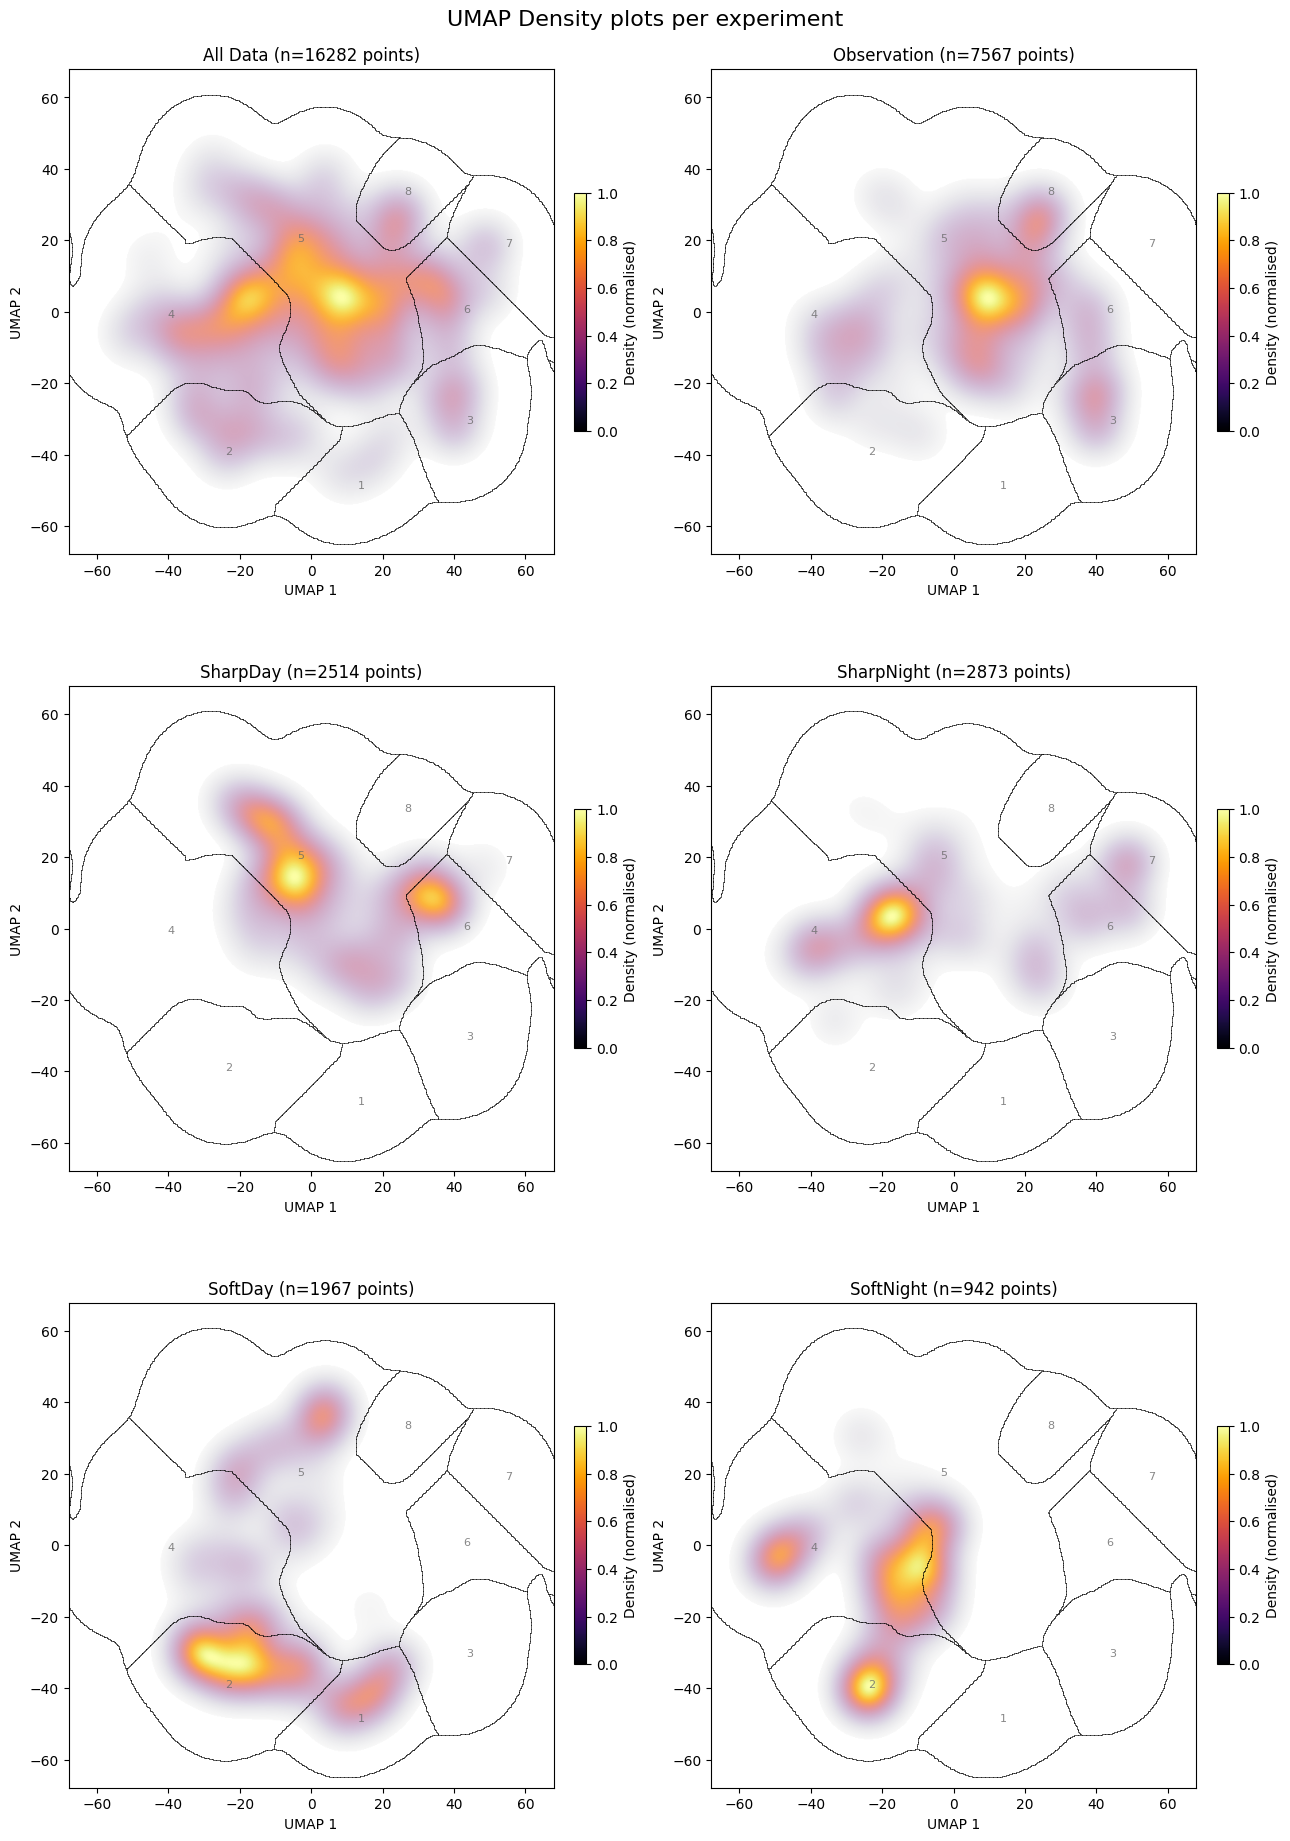

In [29]:
def render_region_background(ax, LL, xx, boundary_x, boundary_y, extent, region_ids):
    ax.scatter(boundary_x, boundary_y, s=0.5, color="black", alpha=0.5, linewidths=0)
    for region_id in region_ids:
        ys, xs = np.where(LL == region_id)
        if xs.size == 0:
            continue
        cx = xx[int(round(xs.mean()))]
        cy = xx[int(round(ys.mean()))]
        ax.text(
            cx, cy, str(region_id),
            ha="center", va="center", fontsize=8, color="dimgray", alpha=0.8,
        )
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])


def density_to_rgba(density, cmap_name="inferno", alpha_floor=0.03):
    """Normalize a density map to its own max and turn it into an RGBA image whose alpha
    channel fades to fully transparent below `alpha_floor`, so low-density background stays
    see-through and the watershed regions underneath remain visible."""
    dnorm = density / density.max()
    rgba = plt.get_cmap(cmap_name)(dnorm)
    alpha = np.where(dnorm < alpha_floor, 0.0, dnorm)
    rgba[..., 3] = alpha
    return rgba


# "All Data" is the base panel: every point that went into the watershed run (zValues),
# regardless of experiment -- not one of the TARGET_EXPERIMENTS pools, so it's computed here
# rather than folded into experiment_density (Section 6).
_, _, all_data_density = mmpy.findPointDensity(zValues, sigma, len(xx), [xx.min(), xx.max()])
panel_density = {"All Data": all_data_density, **experiment_density}
panel_points = {"All Data": zValues, **experiment_points}

fig = plt.figure(figsize=(13, 19))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1])
panel_layout = [
    ("All Data", fig.add_subplot(gs[0, 0])), ("Observation", fig.add_subplot(gs[0, 1])),
    ("SharpDay", fig.add_subplot(gs[1, 0])), ("SharpNight", fig.add_subplot(gs[1, 1])),
    ("SoftDay", fig.add_subplot(gs[2, 0])), ("SoftNight", fig.add_subplot(gs[2, 1])),
]

for exp_name, ax in panel_layout:
    if exp_name not in panel_density:
        ax.axis("off")
        ax.set_title(f"{exp_name} (no data)")
        continue

    render_region_background(ax, LL, xx, boundary_x, boundary_y, extent, region_ids)
    rgba = density_to_rgba(panel_density[exp_name])
    ax.imshow(rgba, origin="lower", extent=extent, aspect="equal")

    n_points = panel_points[exp_name].shape[0]
    ax.set_title(f"{exp_name} (n={n_points} points)")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

    sm = plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, 1))
    fig.colorbar(sm, ax=ax, fraction=0.023, pad=0.04, label="Density (normalised)")

fig.suptitle("UMAP Density plots per experiment", fontsize=16)
plt.tight_layout()

# Save figure to project directory
fig.savefig(PROJECT_DIR / "experiments_heatmaps.png", dpi=300)
plt.show()